## Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, QuantileTransformer
from sklearn.utils.class_weight import compute_class_weight

In [2]:
DATA_DIR = Path("~/ml-backdoor-defense/data/0_raw/CIC_IDS_2017").expanduser()

RANDOM_STATE         = 42
TEST_SIZE            = 0.15
VAL_SIZE             = 0.15
NEAR_CONSTANT_THRESH = 0.99999
CORRELATION_THRESH   = 0.99

# Cap Benign only in train (val/test keep natural distribution).
# Benign dominates >85% of flows → cap prevents train bias.
# Bot/WebAttack kept at natural size (too small to cap).
TRAIN_CAPS = {"Benign": 300_000}

# Destination Port dropped: encodes target service → leakage for attack family detection.
# Dedup MUST run before this drop: PortScan flows differ only by destination port.
DROP_COLS = ["Destination Port"]
LABEL_COL = "Label"

GROUPS = {
    "DoS":        ["DoS slowloris", "DoS Slowhttptest", "DoS Hulk", "DoS GoldenEye"],
    "BruteForce": ["FTP-Patator", "SSH-Patator"],
    "WebAttack":  ["Web Attack - Brute Force", "Web Attack - XSS", "Web Attack - Sql Injection"],
    "Benign":     ["BENIGN"],
    # DDoS, PortScan, Bot: single raw labels, no grouping needed.
}

# Dropped: far too few samples for stable training or backdoor injection.
LABELS_TO_DROP = [
    "Heartbleed",   #    11 samples
    "Infiltration", #    36 samples
]

CLASS_LIST  = ["Benign", "Bot", "BruteForce", "DDoS", "DoS", "PortScan", "WebAttack"]
NUM_CLASSES = len(CLASS_LIST)

CSV_FILES = [
    DATA_DIR / "Monday-WorkingHours.pcap_ISCX.csv",
    DATA_DIR / "Tuesday-WorkingHours.pcap_ISCX.csv",
    DATA_DIR / "Wednesday-workingHours.pcap_ISCX.csv",
    DATA_DIR / "Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv",
    DATA_DIR / "Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv",
    DATA_DIR / "Friday-WorkingHours-Morning.pcap_ISCX.csv",
    DATA_DIR / "Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv",
    DATA_DIR / "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv",
]
assert all(f.exists() for f in CSV_FILES), f"Missing CSV files — check DATA_DIR: {DATA_DIR}"
print(f"Found {len(CSV_FILES)} CSV files  |  {NUM_CLASSES} classes")

Found 8 CSV files  |  7 classes


## 1. Raw Data Quality

In [3]:
rows = []
for path in CSV_FILES:
    df = pd.read_csv(path, low_memory=False)
    df.columns = [c.strip() for c in df.columns]
    num = df.select_dtypes(include=[np.number])
    rows.append({
        "file":       path.name,
        "rows":       len(df),
        "duplicates": int(df.duplicated().sum()),
        "missing":    int(df.isna().sum().sum()),
        "inf":        int(np.isinf(num.to_numpy()).sum()),
        "n_labels":   int(df[LABEL_COL].nunique()),
    })

qdf = pd.DataFrame(rows)
print(qdf.to_string(index=False))
print(f"\nTotal: rows={qdf['rows'].sum():,}  duplicates={qdf['duplicates'].sum():,}  "
      f"missing={qdf['missing'].sum():,}  inf={qdf['inf'].sum():,}")

                                                       file   rows  duplicates  missing  inf  n_labels
                          Monday-WorkingHours.pcap_ISCX.csv 529918       26935       64  810         1
                         Tuesday-WorkingHours.pcap_ISCX.csv 445909       24065      201  327         3
                       Wednesday-workingHours.pcap_ISCX.csv 692703       81909     1008 1586         6
     Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv 170366        6066       20  250         4
Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv 288602       35630       18  396         2
                  Friday-WorkingHours-Morning.pcap_ISCX.csv 191033        6888       28  216         2
       Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv 286467       72353       15  727         2
           Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv 225745        2633        4   64         2

Total: rows=2,830,743  duplicates=256,479  missing=1,358  inf=4,376


## 2. Load, Clean & Filter

In [4]:
def clean_file(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, low_memory=False)
    df.columns = [c.strip() for c in df.columns]
    df = df.drop_duplicates()                        # dedup before dropping identifier cols
    df = df.drop(columns=DROP_COLS, errors="ignore")
    # Fix encoding artifact in Web Attack labels (non-ASCII separator → "-")
    df[LABEL_COL] = (df[LABEL_COL].astype(str).str.strip()
                     .str.replace(r"[^\x00-\x7F]+", "-", regex=True)
                     .str.replace(r"\s+", " ", regex=True))
    for col in df.columns:
        if col != LABEL_COL:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)


frames = [clean_file(p) for p in CSV_FILES]
df_all = pd.concat(frames, ignore_index=True)
del frames

# Preserve raw sub-attack labels (used later for stratified train cap)
raw_labels = df_all[LABEL_COL].copy()

mapping = {label: cls for cls, labels in GROUPS.items() for label in labels}
df_all[LABEL_COL] = raw_labels.replace(mapping)

# Drop unwanted classes (keep raw_labels aligned)
mask = df_all[LABEL_COL].isin(LABELS_TO_DROP)
print(f"Dropping {mask.sum():,} rows for: {LABELS_TO_DROP}")
df_all = df_all.loc[~mask].reset_index(drop=True)
raw_labels = raw_labels.loc[~mask].reset_index(drop=True)

print(f"\nAfter cleaning & filtering: {len(df_all):,} rows × {df_all.shape[1]} cols")
dist = df_all[LABEL_COL].value_counts()
print("\nClass distribution:")
for cls in CLASS_LIST:
    n = dist.get(cls, 0)
    print(f"  {cls:30s}: {n:>10,}  ({100*n/len(df_all):5.1f}%)")

Dropping 47 rows for: ['Heartbleed', 'Infiltration']

After cleaning & filtering: 2,572,593 rows × 78 cols

Class distribution:
  Benign                        :  2,146,899  ( 83.5%)
  Bot                           :      1,948  (  0.1%)
  BruteForce                    :      9,150  (  0.4%)
  DDoS                          :    128,014  (  5.0%)
  DoS                           :    193,745  (  7.5%)
  PortScan                      :     90,694  (  3.5%)
  WebAttack                     :      2,143  (  0.1%)


## 3. Feature Selection

In [5]:
X = df_all.drop(columns=[LABEL_COL]).copy()
y = df_all[LABEL_COL].copy()
print(f"Starting features: {X.shape[1]}")

# Step 1: near-constant
drop1 = [c for c in X if X[c].value_counts(normalize=True, dropna=False).iloc[0] > NEAR_CONSTANT_THRESH]
X = X.drop(columns=drop1)
print(f"  Step 1 — near-constant   dropped ({len(drop1)}): {drop1}")

# Step 2: duplicate-value columns (hash + equals to confirm)
seen, drop2 = {}, []
for col in X:
    h = pd.util.hash_pandas_object(X[col]).sum()
    if h in seen and X[col].equals(X[seen[h]]):
        drop2.append(col)
    else:
        seen[h] = col
X = X.drop(columns=drop2)
print(f"  Step 2 — duplicate-value dropped ({len(drop2)}): {drop2}")

# Step 3: high Pearson correlation
print(f"  Step 3 — correlation matrix ({X.shape[1]} × {len(X):,})…")
upper = X.corr(numeric_only=True).abs().where(
    np.triu(np.ones((X.shape[1],) * 2), k=1).astype(bool))
drop3 = [c for c in upper if (upper[c] > CORRELATION_THRESH).any()]
X = X.drop(columns=drop3)
print(f"  Step 3 — high-corr>{CORRELATION_THRESH}  dropped ({len(drop3)}): {drop3}")

FEATURE_NAMES = list(X.columns)
print(f"\nFinal: {len(FEATURE_NAMES)} features")

Starting features: 77
  Step 1 — near-constant   dropped (8): ['Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']
  Step 2 — duplicate-value dropped (5): ['SYN Flag Count', 'CWE Flag Count', 'Fwd Header Length.1', 'Subflow Fwd Packets', 'Subflow Bwd Packets']
  Step 3 — correlation matrix (64 × 2,572,593)…
  Step 3 — high-corr>0.99  dropped (12): ['Total Backward Packets', 'Total Length of Bwd Packets', 'Fwd IAT Total', 'Fwd IAT Max', 'ECE Flag Count', 'Average Packet Size', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size', 'Subflow Fwd Bytes', 'Subflow Bwd Bytes', 'Idle Max', 'Idle Min']

Final: 52 features


## 4. Split / Scale / Encode

In [6]:
VAL_FRAC = VAL_SIZE / (1 - TEST_SIZE)

X_tv, X_test, y_tv, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE)
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=VAL_FRAC, stratify=y_tv, random_state=RANDOM_STATE)

# Cap Benign only in train.
y_train_raw = raw_labels.loc[y_train.index]
rng = np.random.default_rng(RANDOM_STATE)
keep_idx = pd.Index([])
for cls in CLASS_LIST:
    cls_idx = y_train[y_train == cls].index
    cap = TRAIN_CAPS.get(cls)
    if cap is not None and len(cls_idx) > cap:
        ratio = cap / len(cls_idx)
        sub_labels = y_train_raw.loc[cls_idx]
        sampled = []
        for s in sub_labels.unique():
            s_idx = sub_labels[sub_labels == s].index
            n = int(round(len(s_idx) * ratio))
            sampled.append(rng.choice(s_idx, size=n, replace=False))
        cls_idx = pd.Index(np.concatenate(sampled))
    keep_idx = keep_idx.union(cls_idx)

X_train = X_train.loc[keep_idx].sample(frac=1, random_state=RANDOM_STATE)
y_train = y_train.loc[X_train.index]

scaler = Pipeline([
    ("qt", QuantileTransformer(output_distribution="normal", n_quantiles=1_000,
                               random_state=RANDOM_STATE, subsample=int(1e8))),
    ("mm", MinMaxScaler()),
])
X_train_s = pd.DataFrame(scaler.fit_transform(X_train), columns=FEATURE_NAMES, index=X_train.index)
X_val_s   = pd.DataFrame(scaler.transform(X_val),       columns=FEATURE_NAMES, index=X_val.index)
X_test_s  = pd.DataFrame(scaler.transform(X_test),      columns=FEATURE_NAMES, index=X_test.index)

le = LabelEncoder()
le.fit(CLASS_LIST)
y_train_enc = le.transform(y_train)
y_val_enc   = le.transform(y_val)
y_test_enc  = le.transform(y_test)

class_weights = compute_class_weight("balanced", classes=np.arange(NUM_CLASSES), y=y_train_enc)

print(f"train {len(X_train):,}  |  val {len(X_val):,}  |  test {len(X_test):,}")
tbl = pd.DataFrame({
    "class":   le.classes_,
    "train_n": [(y_train_enc == i).sum() for i in range(NUM_CLASSES)],
    "pct":     [f"{100*(y_train_enc==i).sum()/len(y_train_enc):.2f}%" for i in range(NUM_CLASSES)],
    "weight":  class_weights.round(2),
})
print(tbl.to_string(index=False))

train 597,986  |  val 385,889  |  test 385,889
     class  train_n    pct  weight
    Benign   300000 50.17%    0.28
       Bot     1364  0.23%   62.63
BruteForce     6405  1.07%   13.34
      DDoS    89610 14.99%    0.95
       DoS   135621 22.68%    0.63
  PortScan    63486 10.62%    1.35
 WebAttack     1500  0.25%   56.95


## 5. Sanity Check

In [7]:
for name, Xs, ye in [("train", X_train_s, y_train_enc),
                     ("val",   X_val_s,   y_val_enc),
                     ("test",  X_test_s,  y_test_enc)]:
    n_nan = int(Xs.isna().sum().sum())
    n_inf = int(np.isinf(Xs.to_numpy()).sum())
    missing = [le.classes_[i] for i in range(NUM_CLASSES) if (ye == i).sum() == 0]
    tag = "OK" if n_nan == 0 and n_inf == 0 and not missing else "FAIL"
    print(f"  [{tag}] {name:5s}  shape={Xs.shape}  NaN={n_nan}  inf={n_inf}"
          + (f"  missing={missing}" if missing else ""))

  [OK] train  shape=(597986, 52)  NaN=0  inf=0
  [OK] val    shape=(385889, 52)  NaN=0  inf=0
  [OK] test   shape=(385889, 52)  NaN=0  inf=0


## 6. MLP Baseline

In [8]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def to_tensor(Xdf, yarr):
    return (torch.tensor(Xdf.to_numpy(), dtype=torch.float32),
            torch.tensor(yarr, dtype=torch.long))

X_tr_t, y_tr_t = to_tensor(X_train_s, y_train_enc)
X_va_t, y_va_t = to_tensor(X_val_s,   y_val_enc)
X_te_t, y_te_t = to_tensor(X_test_s,  y_test_enc)

BATCH = 4096
train_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=BATCH,   shuffle=True,  num_workers=0, pin_memory=(device.type == "cuda"))
val_loader   = DataLoader(TensorDataset(X_va_t, y_va_t), batch_size=BATCH*4, shuffle=False, num_workers=0)


class MLP(nn.Module):
    def __init__(self, in_dim, hidden, out_dim, p=0.3):
        super().__init__()
        layers, prev = [], in_dim
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(p)]
            prev = h
        layers.append(nn.Linear(prev, out_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


model     = MLP(X_tr_t.shape[1], [256, 128, 64], NUM_CLASSES).to(device)
cw_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=cw_tensor)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

print(f"Device: {device}  |  Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Device: cuda  |  Trainable params: 56,071


Epoch 01/20  train=0.4712  val_loss=0.2787  val_f1=0.5748 <--
Epoch 02/20  train=0.1468  val_loss=0.1967  val_f1=0.6241 <--
Epoch 03/20  train=0.1137  val_loss=0.1668  val_f1=0.6175
Epoch 04/20  train=0.0978  val_loss=0.1517  val_f1=0.6337 <--
Epoch 05/20  train=0.0916  val_loss=0.1405  val_f1=0.6503 <--
Epoch 06/20  train=0.0838  val_loss=0.1196  val_f1=0.6594 <--
Epoch 07/20  train=0.0796  val_loss=0.1183  val_f1=0.6658 <--
Epoch 08/20  train=0.0755  val_loss=0.1150  val_f1=0.6571
Epoch 09/20  train=0.0753  val_loss=0.1131  val_f1=0.6649
Epoch 10/20  train=0.0695  val_loss=0.1126  val_f1=0.6652
Epoch 11/20  train=0.0675  val_loss=0.1114  val_f1=0.6789 <--
Epoch 12/20  train=0.0660  val_loss=0.1035  val_f1=0.6729
Epoch 13/20  train=0.0632  val_loss=0.0983  val_f1=0.6888 <--
Epoch 14/20  train=0.0625  val_loss=0.1017  val_f1=0.6833
Epoch 15/20  train=0.0609  val_loss=0.1015  val_f1=0.6851
Epoch 16/20  train=0.0603  val_loss=0.0961  val_f1=0.6828
Epoch 17/20  train=0.0589  val_loss=0.09

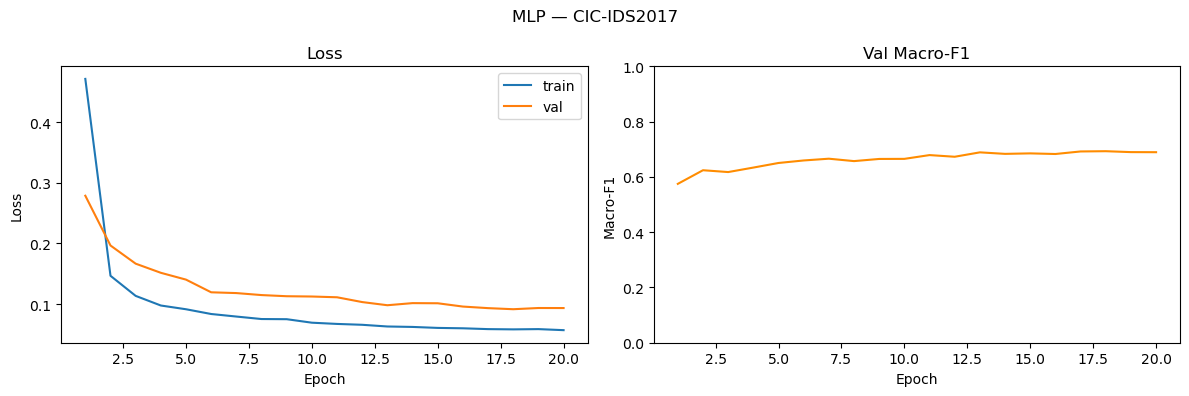

In [9]:
def _eval(model, loader):
    model.eval()
    loss_sum, preds_all, labels_all = 0.0, [], []
    with torch.no_grad():
        for Xb, yb in loader:
            Xb, yb = Xb.to(device), yb.to(device)
            logits = model(Xb)
            loss_sum += criterion(logits, yb).item() * len(yb)
            preds_all.extend(logits.argmax(1).cpu().tolist())
            labels_all.extend(yb.cpu().tolist())
    mf1 = f1_score(labels_all, preds_all, average="macro", zero_division=0)
    return loss_sum / len(labels_all), mf1


MAX_EPOCHS, PATIENCE = 20, 5
history = {"train_loss": [], "val_loss": [], "val_f1": []}
best_f1, no_imp, best_state = 0.0, 0, None

for ep in range(1, MAX_EPOCHS + 1):
    model.train()
    run = 0.0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(Xb), yb)
        loss.backward()
        optimizer.step()
        run += loss.item() * len(yb)
    scheduler.step()

    tl = run / len(y_tr_t)
    vl, vf1 = _eval(model, val_loader)
    history["train_loss"].append(tl)
    history["val_loss"].append(vl)
    history["val_f1"].append(vf1)

    if vf1 > best_f1 + 1e-5:
        best_f1, no_imp = vf1, 0
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        marker = " <--"
    else:
        no_imp += 1
        marker = ""

    print(f"Epoch {ep:02d}/{MAX_EPOCHS}  train={tl:.4f}  val_loss={vl:.4f}  val_f1={vf1:.4f}{marker}")
    if no_imp >= PATIENCE:
        print(f"\nEarly stop at epoch {ep}.")
        break

model.load_state_dict(best_state)
print(f"\nBest val_macro_f1 = {best_f1:.4f}")

eps = range(1, len(history["train_loss"]) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(eps, history["train_loss"], label="train")
ax1.plot(eps, history["val_loss"], label="val")
ax1.set(xlabel="Epoch", ylabel="Loss", title="Loss")
ax1.legend()
ax2.plot(eps, history["val_f1"], color="darkorange")
ax2.set(xlabel="Epoch", ylabel="Macro-F1", title="Val Macro-F1", ylim=[0, 1])
plt.suptitle("MLP — CIC-IDS2017")
plt.tight_layout()
plt.show()

## 7. Test Evaluation

TEST SET — Classification Report
              precision    recall  f1-score   support

      Benign     0.9993    0.9291    0.9629    322035
         Bot     0.0300    0.9966    0.0582       292
  BruteForce     0.7063    0.9738    0.8187      1373
        DDoS     0.9878    0.9994    0.9936     19202
         DoS     0.9416    0.9910    0.9657     29062
    PortScan     0.9846    0.9987    0.9916     13604
   WebAttack     0.0287    0.9875    0.0558       321

    accuracy                         0.9400    385889
   macro avg     0.6683    0.9823    0.6924    385889
weighted avg     0.9912    0.9400    0.9637    385889



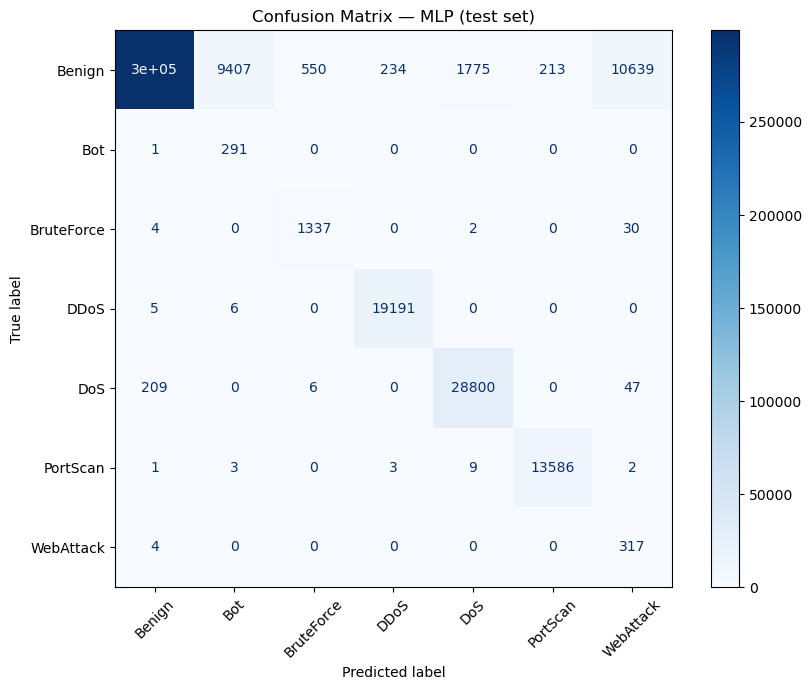


Macro-F1: 0.6924  FAIL  (target >= 0.80)

Per-class F1:
  Benign              : 0.9629  ###################
  Bot                 : 0.0582  #
  BruteForce          : 0.8187  ################
  DDoS                : 0.9936  ###################
  DoS                 : 0.9657  ###################
  PortScan            : 0.9916  ###################
  WebAttack           : 0.0558  #


In [10]:
test_loader = DataLoader(TensorDataset(X_te_t, y_te_t), batch_size=BATCH * 4, shuffle=False)
model.eval()
preds, labels = [], []
with torch.no_grad():
    for Xb, yb in test_loader:
        preds.extend(model(Xb.to(device)).argmax(1).cpu().tolist())
        labels.extend(yb.tolist())
preds, labels = np.array(preds), np.array(labels)

print("=" * 60)
print("TEST SET — Classification Report")
print("=" * 60)
print(classification_report(labels, preds, target_names=le.classes_, digits=4))

fig, ax = plt.subplots(figsize=(9, 7))
ConfusionMatrixDisplay(confusion_matrix(labels, preds), display_labels=le.classes_).plot(
    ax=ax, colorbar=True, cmap="Blues", xticks_rotation=45)
ax.set_title("Confusion Matrix — MLP (test set)"); plt.tight_layout(); plt.show()

macro_f1     = f1_score(labels, preds, average="macro")
per_class_f1 = f1_score(labels, preds, average=None)
print(f"\nMacro-F1: {macro_f1:.4f}  {'PASS' if macro_f1 >= 0.80 else 'FAIL  (target >= 0.80)'}")
print("\nPer-class F1:")
for i, cls in enumerate(le.classes_):
    bar = "#" * int(per_class_f1[i] * 20)
    print(f"  {cls:20s}: {per_class_f1[i]:.4f}  {bar}")